In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/HateSpeechDataset.csv')
df = df[df['Label'] != 'Label']  # Remove header rows if duplicated
df['Content'] = df['Content'].astype(str)
df['Label'] = df['Label'].astype(int)


In [ ]:
from sklearn.model_selection import train_test_split

X = df['Content']
y = df['Label']

X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)


In [ ]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
joblib.dump(logreg_model, '/content/drive/MyDrive/logreg_model.pkl')
joblib.dump(vectorizer, '/content/drive/MyDrive/logreg_vectorizer.pkl')


['/content/drive/MyDrive/logreg_vectorizer.pkl']

RUN FROM **HERE**

In [ ]:
vectorizer = joblib.load('/content/drive/MyDrive/vectorizer.pkl')

In [ ]:
logreg_model = joblib.load('/content/drive/MyDrive/logreg_model.pkl')

In [ ]:
def predict_logreg(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    vect = vectorizer.transform([text])
    pred = logreg_model.predict(vect)[0]
    return "🚫 Hate Speech" if pred == 1 else "✅ Not Hate Speech"


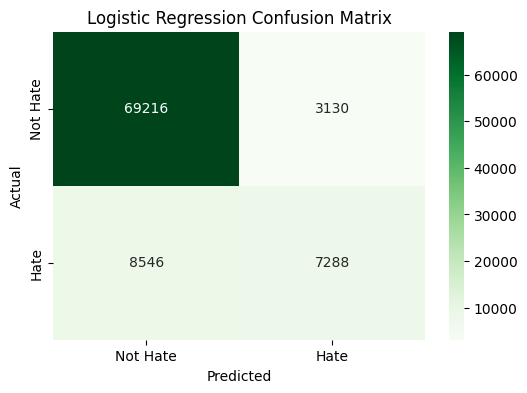

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = logreg_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Hate', 'Hate'], yticklabels=['Not Hate', 'Hate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Not Hate', 'Hate']))


              precision    recall  f1-score   support

    Not Hate       0.89      0.96      0.92     72346
        Hate       0.70      0.46      0.56     15834

    accuracy                           0.87     88180
   macro avg       0.79      0.71      0.74     88180
weighted avg       0.86      0.87      0.86     88180



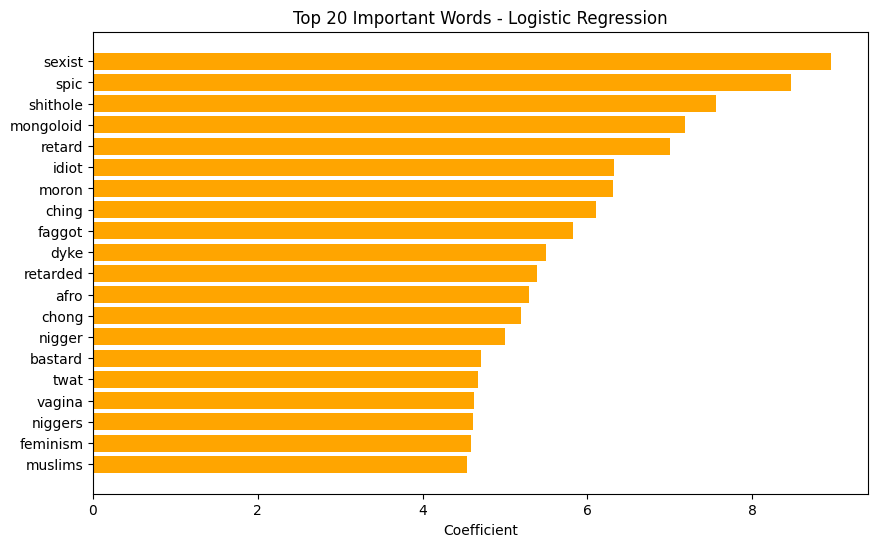

In [ ]:
coeffs = logreg_model.coef_[0]
top_idx = np.argsort(coeffs)[-20:]
top_words = vectorizer.get_feature_names_out()[top_idx]
top_coeffs = coeffs[top_idx]

plt.figure(figsize=(10,6))
plt.barh(top_words, top_coeffs, color='orange')
plt.xlabel("Coefficient")
plt.title("Top 20 Important Words - Logistic Regression")
plt.show()


In [ ]:
predict_logreg("You are disgusting and should be banned")

'🚫 Hate Speech'

In [ ]:
predict_logreg("You are a loving person")

'✅ Not Hate Speech'

In [ ]:
predict_logreg("You are a bastard")

'🚫 Hate Speech'